# Statistics for Problem transformation experiments

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import result_handler
import os
from sklearn.metrics import roc_auc_score
import scipy.stats as stats


#setting filepaths of the results

pi_results_filepath = "../prediction_results/PI_results/PI_"

nnrti_results_filepath = "../prediction_results/NNRTI_results/NNRTI_"

nrti_results_filepath = "../prediction_results/NRTI_results/NRTI_"

ini_results_filepath = "../prediction_results/INI_results/INI_"



#creating lists with filepaths for later visualisation
filepath_list = [ini_results_filepath, nnrti_results_filepath, nrti_results_filepath, pi_results_filepath]




#setting filepaths for the benchmarking datasets

pi_results_filepath_ml = "../prediction_results/PI_results/benchmarkings/PI_"

nnrti_results_filepath_ml = "../prediction_results/NNRTI_results/benchmarkings/NNRTI_"

nrti_results_filepath_ml = "../prediction_results/NRTI_results/benchmarkings/NRTI_"

ini_results_filepath_ml = "../prediction_results/INI_results/benchmarkings/INI_"



#creating lists with filepaths for later visualisation
filepath_list_ml = [ini_results_filepath_ml, nnrti_results_filepath_ml, nrti_results_filepath_ml, pi_results_filepath_ml]


## Binary relevance with TabPFN predicts labels on par with state of the art

         INI     NNRTI      NRTI        PI
0   0.878387  0.822059  0.890281  0.930793
1   0.857204  0.846849  0.890480  0.921899
2   0.878495  0.825252  0.882219  0.927747
3   0.858871  0.823529  0.882916  0.929575
4   0.847581  0.797521  0.888287  0.923480
5   0.879946  0.841261  0.880528  0.925676
6   0.897742  0.810504  0.882216  0.926045
7   0.871774  0.851387  0.893366  0.923847
8   0.876828  0.836765  0.879431  0.920799
9   0.873548  0.843950  0.891279  0.932497
10  0.881559  0.803361  0.880322  0.926526
         INI     NNRTI      NRTI        PI
0   0.025415  0.027228  0.009426  0.006293
1   0.007778  0.018313  0.007047  0.009261
2   0.037988  0.016403  0.010194  0.005088
3   0.028796  0.029189  0.009574  0.005984
4   0.019422  0.040854  0.009284  0.009353
5   0.035472  0.032258  0.007968  0.005564
6   0.038854  0.024134  0.007578  0.007483
7   0.024922  0.021179  0.005638  0.007288
8   0.033695  0.017101  0.010337  0.010152
9   0.022250  0.020915  0.005679  0.006212
10  0.03694

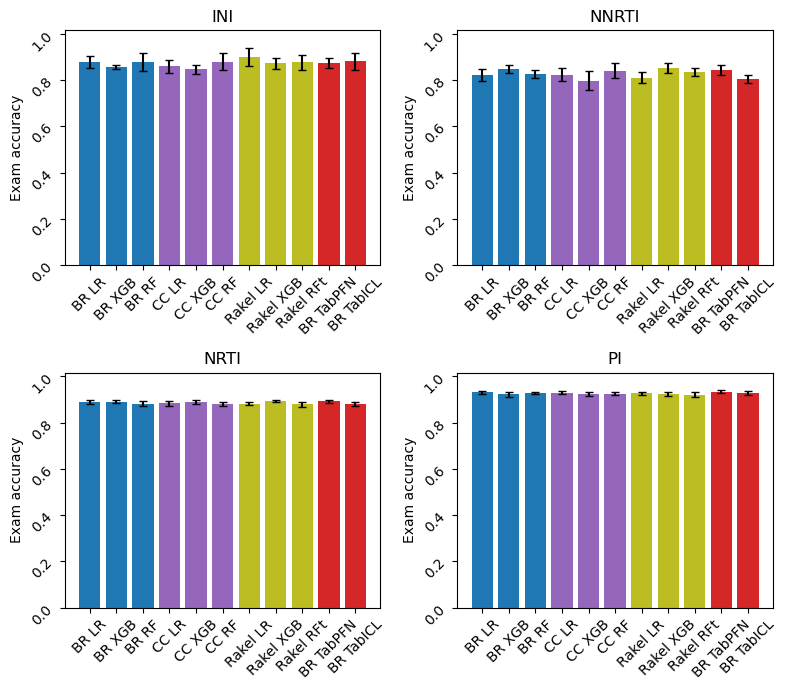

In [2]:


ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest", "Rakeld_lr", "Rakeld_xgb", "Rakeld_forest"]

ending = "_5_fold.csv"

sub_accs_fold_mean, sub_accs_fold_std = result_handler.calc_metrics(filepath_list_ml, ml_models, result_handler.exam_acc, {"nan_mode": "warning"}, ending=ending, drop_na=False)


files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv"]

tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

[sub_accs_fold_mean[x].extend(tmp_sub_accs_fold_mean[x]) for x in sub_accs_fold_mean.keys()]
[sub_accs_fold_std[x].extend(tmp_sub_accs_fold_std[x]) for x in sub_accs_fold_std.keys()]


df_sub_accs_groups_mean = pd.DataFrame(sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(sub_accs_fold_std)

print(df_sub_accs_groups_mean)
print(df_sub_accs_groups_std)





models_w_TabPFN = ["BR LR", "BR XGB", "BR RF", "CC LR", "CC XGB", "CC RF", "Rakel LR", "Rakel XGB", "Rakel RFt", "BR TabPFN", "BR TabICL"]

color = ["tab:blue"] * 3 + ["tab:purple"] * 3 + ["tab:olive"] * 3 + ["tab:red"] * 2

fig, axs = plt.subplots(2, 2, figsize=(8, 7))


axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    labels = models_w_TabPFN
    p = axs[i].bar(labels, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(labels, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")


    #axs[i].bar_label(p, label_type="edge", padding=12, fmt="%.3f")

    axs[i].grid(False)
    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title(drug)

fig.tight_layout()


#plt.savefig("../figures/02_BR_benchmark_soa/Benchmark_comp_BR_exam_acc_new2.png")


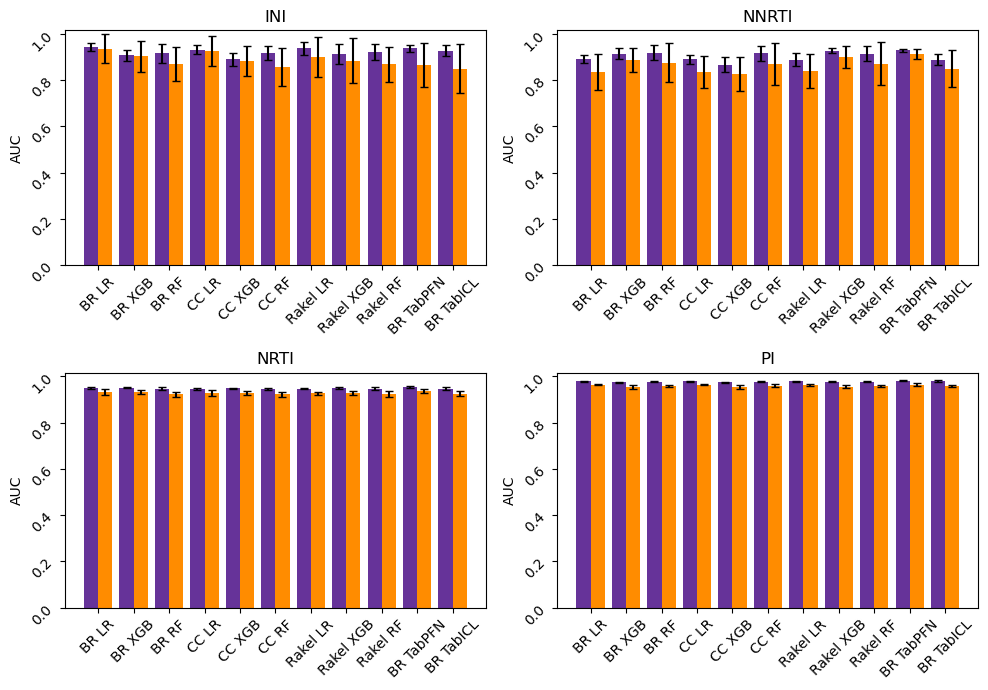

In [6]:


ml_models = ["BR_LR", "BR_XGB", "BR_forest", "CC_LR", "CC_xgb", "CC_forest", "Rakeld_lr", "Rakeld_xgb", "Rakeld_forest"]

ending = "_5_fold_probabilities.csv"

roc_auc_mean, roc_auc_std = result_handler.calc_metrics(filepath_list_ml, ml_models, roc_auc_score, {"average": "macro"}, ending=ending, drop_na=False)


files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_probabilities_5_fold_tabicl_homebrew_prediction_new_save_woNaN.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True)

[roc_auc_mean[x].extend(tmp_roc_auc_mean[x]) for x in roc_auc_mean.keys()]
[roc_auc_std[x].extend(tmp_roc_auc_std[x]) for x in roc_auc_std.keys()]


df_roc_auc_mean = pd.DataFrame(roc_auc_mean)
df_roc_auc_std = pd.DataFrame(roc_auc_std)

prc_auc_mean, prc_auc_std = result_handler.calc_metrics(filepath_list_ml, ml_models, result_handler.prc_auc_score, {"multiclass":"ovo"}, ending=ending, drop_na=False)


tmp_prc_auc_mean, tmp_prc_auc_std = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovo"}, drop_na=True)

[prc_auc_mean[x].extend(tmp_prc_auc_mean[x]) for x in prc_auc_mean.keys()]
[prc_auc_std[x].extend(tmp_prc_auc_std[x]) for x in prc_auc_std.keys()]


df_prc_auc_mean = pd.DataFrame(prc_auc_mean)
df_prc_auc_std = pd.DataFrame(prc_auc_std)




models_w_TabPFN = ["BR LR", "BR XGB", "BR RF", "CC LR", "CC XGB", "CC RF", "Rakel LR", "Rakel XGB", "Rakel RF", "BR TabPFN", "BR TabICL"]

color = ["rebeccapurple", "darkorange"]

labels = models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(10, 7))
#fig.tight_layout()

axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):


    multiplier = -0.5

    offset = width * multiplier
    rects = axs[i].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC", color=color[0])
    #axs[i].bar_label(rects, fmt='%.2f', padding=3)
    axs[i].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[i].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC", color=color[1])
    #axs[i].bar_label(rects2, fmt='%.2f', padding=3)
    axs[i].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1


    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")

    axs[i].set_xticks(x)
    axs[i].set_xticklabels(labels)
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('AUC')
    axs[i].set_ylim(0, 1.0  * 1.015)
    axs[i].set_title(drug)

fig.tight_layout()



plt.savefig("../figures/02_BR_benchmark_soa/Benchmark_comp_BR_ROC_prc_auc_new2.png")


## Simple Classifier Chains do not improve predictive results compared to binary relevance for TabPFN

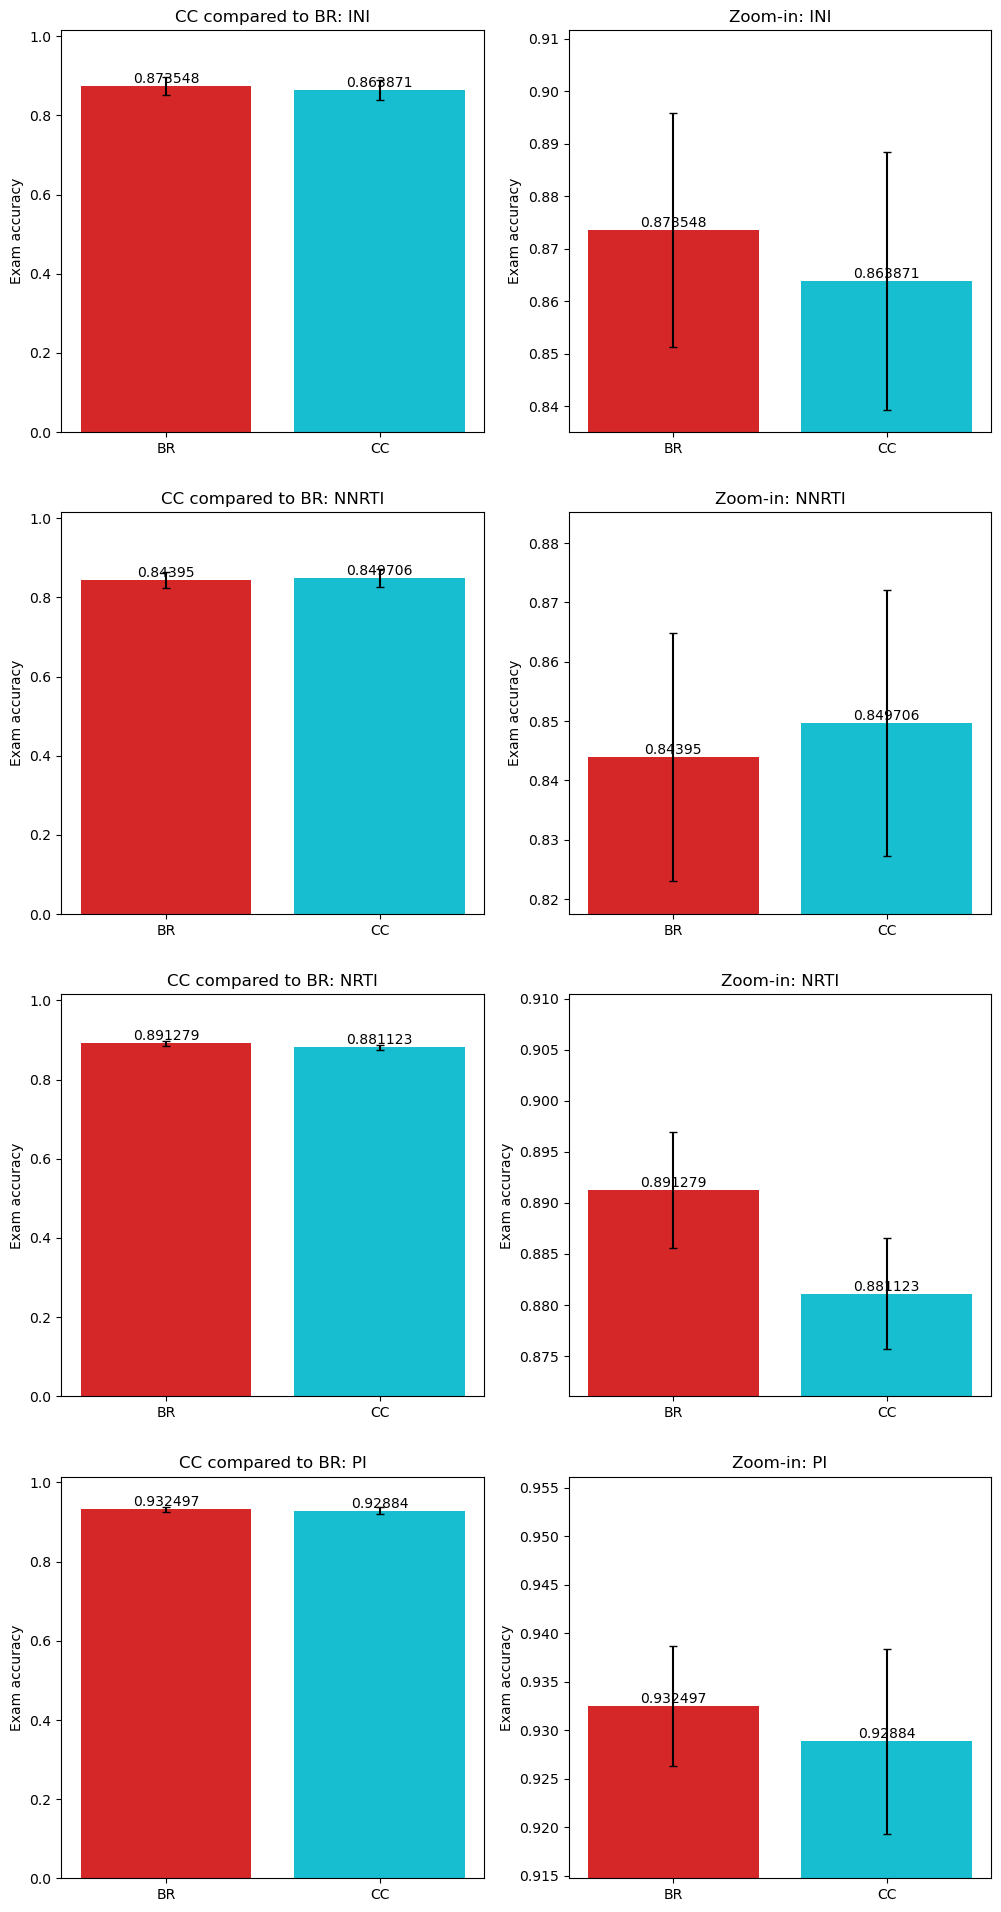

In [21]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR", "CC"]

color = ["tab:red"] + ["tab:cyan"]

fig, axs = plt.subplots(4, 2, figsize=(12, 24))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    j = i * 2

    p = axs[j].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[j].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j].set_ylabel('Exam accuracy')
    axs[j].set_ylim(0, 1.015)
    axs[j].set_title('CC compared to BR: ' + drug)

    p2 = axs[j +1].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[j +1].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j +1].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j +1].set_ylabel('Exam accuracy')
    axs[j+1].set_ylim(max(0, (df_sub_accs_groups_mean[drug].min() - df_sub_accs_groups_std[drug].max()) * 0.995), min(1.0 + df_sub_accs_groups_std[drug].max(), (df_sub_accs_groups_mean[drug].max() + df_sub_accs_groups_std[drug].max())  * 1.015))
    axs[j +1].set_title('Zoom-in: ' + drug)


#plt.savefig("../figures/03_CC_better_BR/CC_better_exam_acc.png")



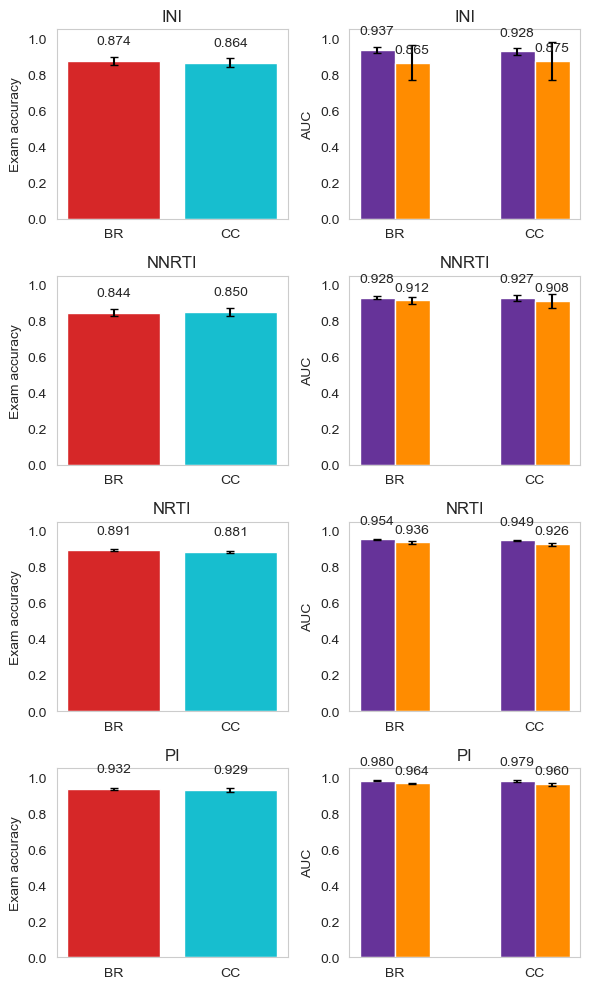

In [17]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True)

df_roc_auc_mean = pd.DataFrame(tmp_roc_auc_mean)
df_roc_auc_std = pd.DataFrame(tmp_roc_auc_std)

tmp_prc_auc_mean, tmp_prc_auc_std = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovo"}, drop_na=True)

df_prc_auc_mean = pd.DataFrame(tmp_prc_auc_mean)
df_prc_auc_std = pd.DataFrame(tmp_prc_auc_std)



models_w_TabPFN = ["BR", "CC"]

color = ["tab:red"]  + ["tab:cyan"]

labels = models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

fig, axs = plt.subplots(4, 2, figsize=(6, 10))


axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):

    j = i * 2

    p = axs[j].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[j].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j].bar_label(p, label_type="edge", fmt='%.3f', padding=10)

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j].set_ylabel('Exam accuracy')
    axs[j].set_ylim(0, 1.05)
    axs[j].set_title(drug)

    multiplier = -0.5

    offset = width * multiplier
    rects = axs[j + 1].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC", color="rebeccapurple")
    axs[j + 1].bar_label(rects, fmt='%.3f', padding=9)
    axs[j + 1].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[j + 1].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC", color="darkorange")
    axs[j + 1].bar_label(rects2, fmt='%.3f', padding=5)
    axs[j + 1].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1


    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")
    axs[j].grid(False)
    axs[j + 1].grid(False)
    axs[j + 1].set_xticks(x)
    axs[j + 1].set_xticklabels(models_w_TabPFN)
    #axs[j + 1].tick_params(rotation=45)
    axs[j + 1].set_ylabel('AUC')
    axs[j+1].set_ylim(0, 1.05)
    axs[j + 1].set_title(drug)

fig.tight_layout()

#plt.show()

plt.savefig("../figures/03_CC_better_BR/Comparison_BR_CC_new.png")

## Inclusion of targets with missing values improves predictive power

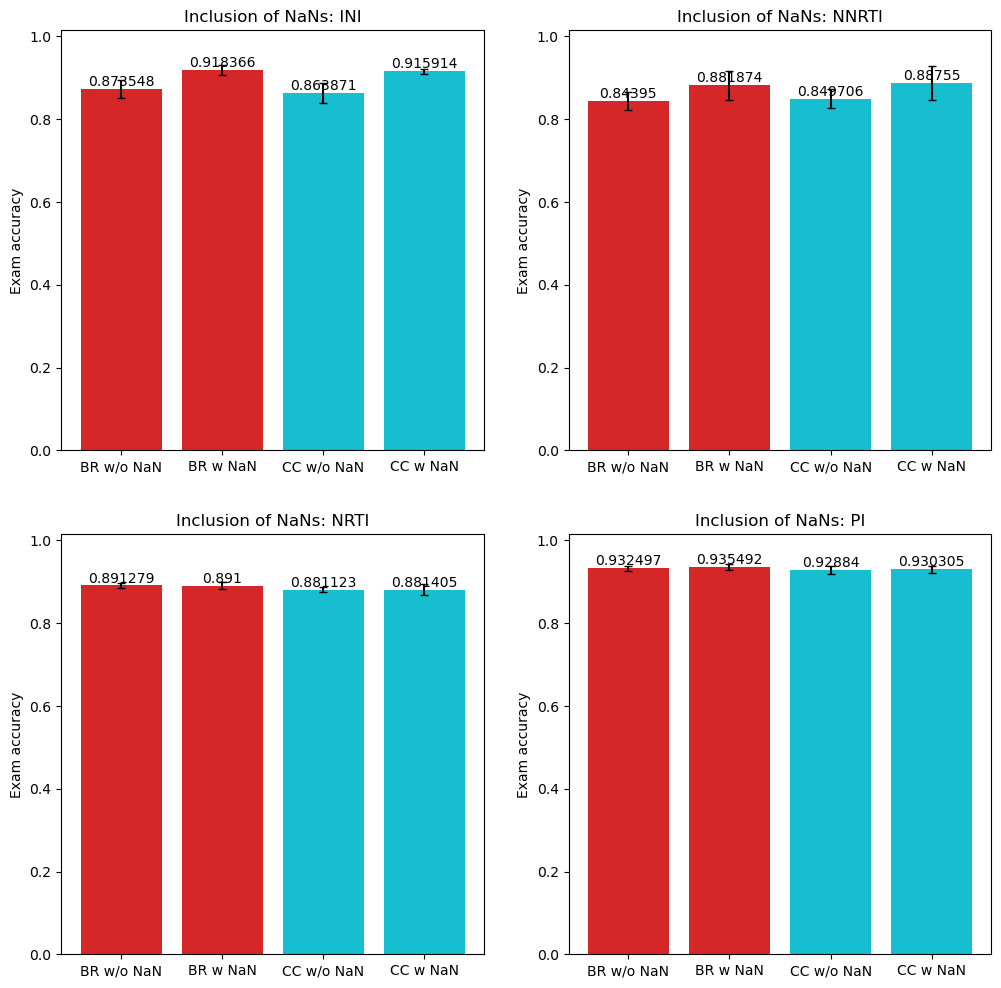

In [15]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

color = ["tab:red"] * 2 + ["tab:cyan"] * 2

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge")

    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.015)
    axs[i].set_title('Inclusion of NaNs: ' + drug)


plt.savefig("../figures/04_Incl_NaN/Incl_NaN_Exam_Acc.png")



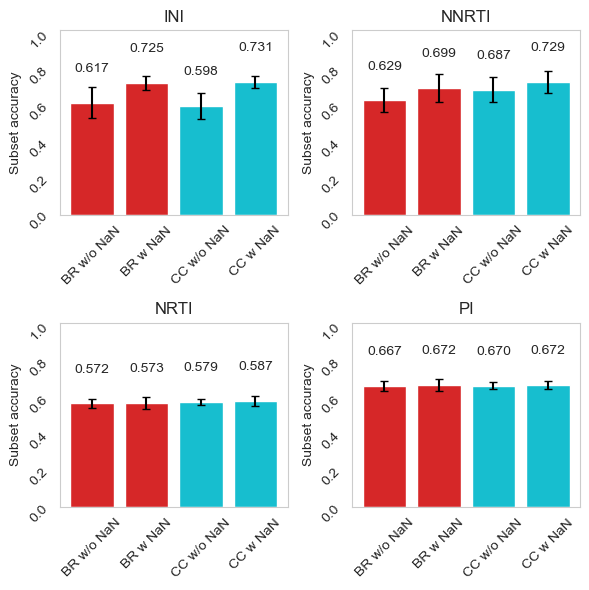

In [30]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.subset_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

#plt.bar(df_sub_accs)

models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

color = ["tab:red"] * 2 + ["tab:cyan"] * 2

fig, axs = plt.subplots(2, 2, figsize=(6, 6))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):

    #print(axs[i])
    #print(i)

    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge", fmt='%.3f', padding=20)

    axs[i].grid(False)
    axs[i].tick_params(rotation=45)
    #axs[i].set_xticks(x)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(0, 1.015)
    axs[i].set_title(drug)

fig.tight_layout()


plt.savefig("../figures/04_Incl_NaN/Incl_NaN_subset_Acc_new.png")



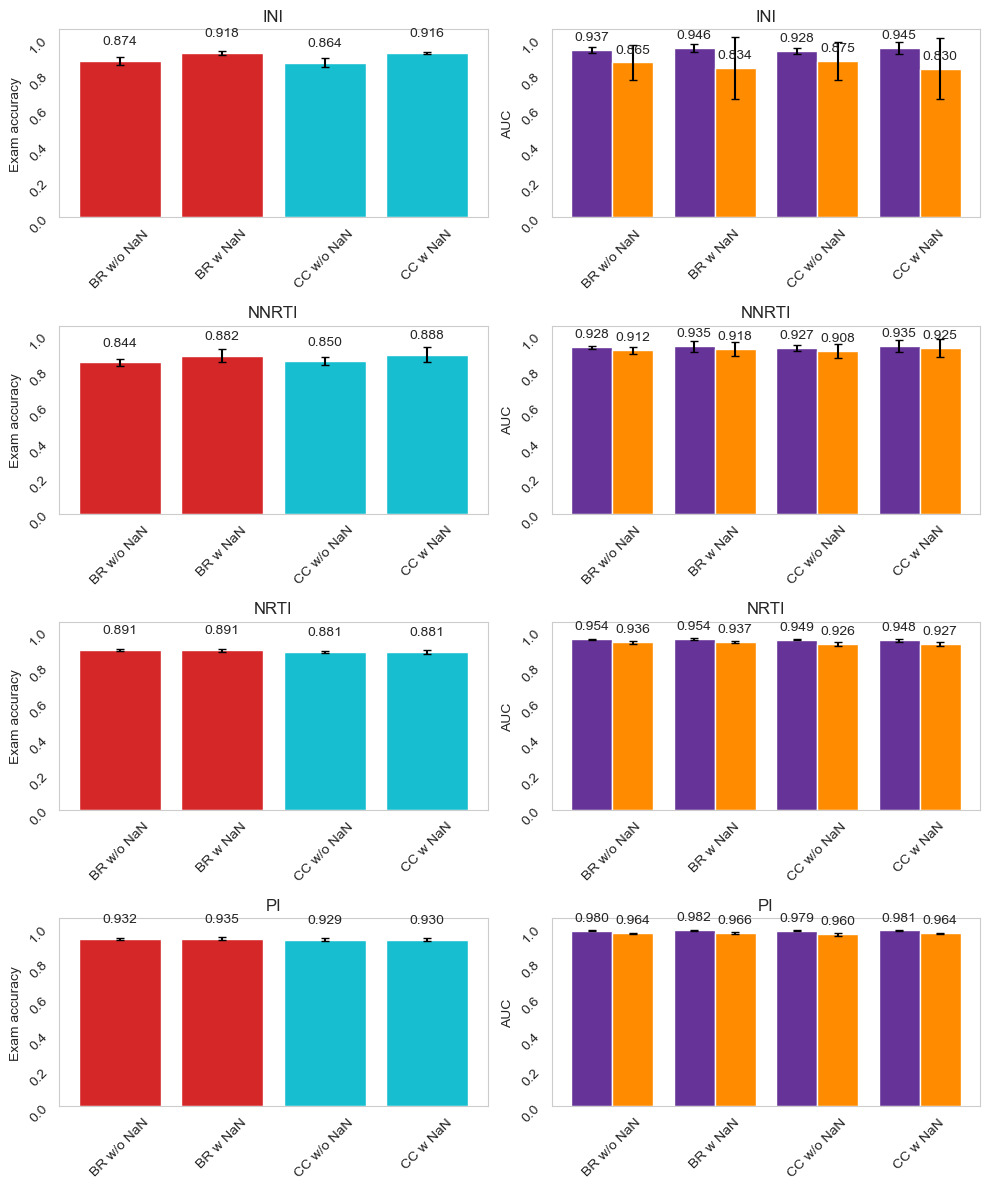

In [24]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)


files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv", "Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_new_save.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True)

df_roc_auc_mean = pd.DataFrame(tmp_roc_auc_mean)
df_roc_auc_std = pd.DataFrame(tmp_roc_auc_std)

tmp_prc_auc_mean, tmp_prc_auc_std = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovo"}, drop_na=True)

df_prc_auc_mean = pd.DataFrame(tmp_prc_auc_mean)
df_prc_auc_std = pd.DataFrame(tmp_prc_auc_std)


models_w_TabPFN = ["BR w/o NaN", "BR w NaN", "CC w/o NaN", "CC w NaN"]

color = ["tab:red"] * 2 + ["tab:cyan"] * 2

labels = models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(4, 2, figsize=(10, 12))
#fig.tight_layout()

axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):

    j = i * 2

    p = axs[j].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[j].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[j].bar_label(p, label_type="edge", fmt='%.3f', padding=10)

    axs[j].grid(False)
    #axs[i].set_xticks(x)
    axs[j].tick_params(rotation=45)
    #axs[i].set_xticklabels(target_ml["Drug"])
    axs[j].set_ylabel('Exam accuracy')
    axs[j].set_ylim(0, 1.05)
    axs[j].set_title(drug)

    multiplier = -0.5

    offset = width * multiplier
    rects = axs[j + 1].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC", color="rebeccapurple")
    axs[j + 1].bar_label(rects, fmt='%.3f', padding=5)
    axs[j + 1].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[j + 1].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC", color="darkorange")
    axs[j + 1].bar_label(rects2, fmt='%.3f', padding=5)
    axs[j + 1].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1


    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")
    axs[j + 1].grid(False)
    axs[j + 1].set_xticks(x)
    axs[j + 1].set_xticklabels(models_w_TabPFN)
    axs[j + 1].tick_params(rotation=45)
    axs[j + 1].set_ylabel('AUC')
    axs[j+1].set_ylim(0, 1.05)
    axs[j + 1].set_title(drug)

fig.tight_layout()



plt.savefig("../figures/04_Incl_NaN/Comparison_W_wo_NaN_new.png")

## Classifier Chain Ensembles do not improve the results

        INI     NNRTI      NRTI        PI
0  0.910279  0.856326  0.885747  0.933818
1  0.916578  0.899228  0.887165  0.929739
2  0.921300  0.897191  0.884353  0.930536
3  0.906344  0.850768  0.885970  0.931916
4  0.910083  0.865860  0.891190  0.932670
0  0.863871  0.849706  0.881123  0.928840
1  0.915914  0.887550  0.881405  0.930305


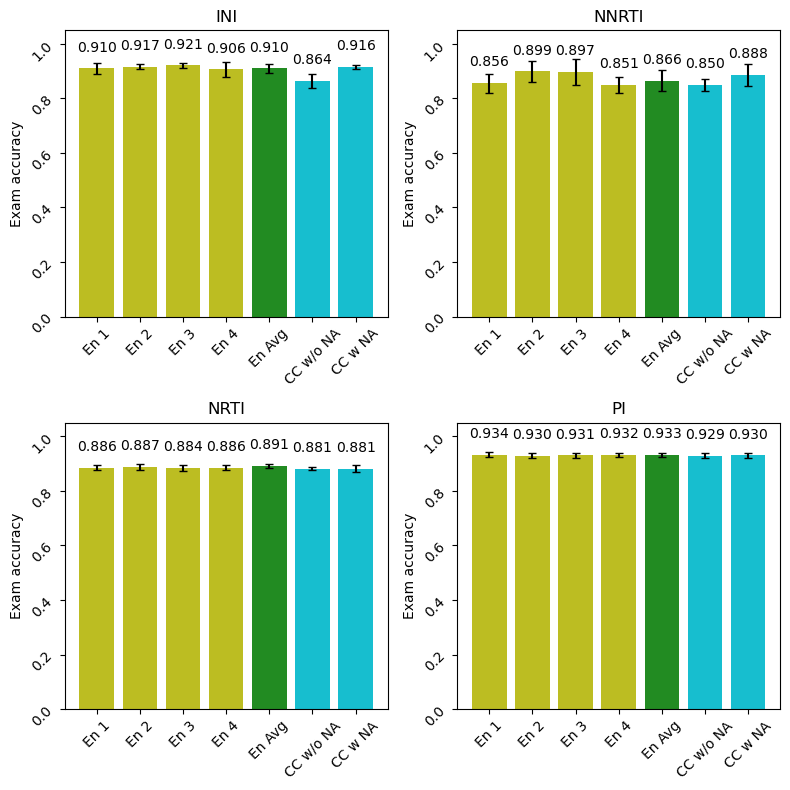

In [6]:

def cc_ensemble_stat(files, filename, drop_na, metric, metric_name, kwargs, fig_name=None):


    ensemble_accs_mean = {}
    ensemble_accs_std = {}

    for path in filepath_list:

        chains = os.listdir(path + filename)

        chain_list = []
        chain_acc_list_mean = []
        chain_acc_list_std = []

        true_labels = None

        for chain in chains:
            #print(path+filename+chain)

            results = pd.read_csv(path + filename + chain)

            #print(path+filename+chain)

            if drop_na:
                results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

            pred_labels = results.filter(regex="Pred_*")

            true_labels = results.filter(regex="True_*")
            #pred_labels = (pred_probas > 0.5) * 1.0

            subs_accs_groups = results.groupby(by="kFolds").apply(
                lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
                include_groups=False)

            #print(true_labels == true_labels_old)
            #print(pred_labels == pred_labels_old)

            chain_list.append(pred_labels)

            chain_acc_list_mean.append(subs_accs_groups.mean())
            chain_acc_list_std.append(subs_accs_groups.std())
            #chain_acc_list.append(sub_acc)

        #chain_list = np.array(chain_list)

        columns = chain_list[0].columns.values.tolist()

        ave_chain = (np.mean(np.array(chain_list), axis=0) > 0.5) * 1

        ave_chain_df = pd.DataFrame(ave_chain, columns=columns)

        #print(ave_chain_df.shape)
        kfold = results["kFolds"]

        true_labels.reset_index(drop=True, inplace=True)
        ave_chain_df.reset_index(drop=True, inplace=True)
        kfold.reset_index(drop=True, inplace=True)

        ave_chain_complete = pd.concat([true_labels, ave_chain_df, kfold], axis=1)



        #true_labels = ave_chain_df.filter(regex="True_*")
        #pred_labels = (ave_chain_df > 0.5) * 1.0

        #print(ave_chain_complete)

        subs_accs_groups = ave_chain_complete.groupby(by="kFolds").apply(
            lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
            include_groups=False)

        #sub_acc = result_handler.subset_acc(pred_labels, true_labels, nan_mode="ignore")

        chain_acc_list_mean.append(subs_accs_groups.mean())
        chain_acc_list_std.append(subs_accs_groups.std())
        #chain_acc_list.append(sub_acc)

        ensemble_accs_mean.update({path.split("/")[-1].strip("_"): chain_acc_list_mean})
        ensemble_accs_std.update({path.split("/")[-1].strip("_"): chain_acc_list_std})



    df_ensemble_accs_groups_mean = pd.DataFrame(ensemble_accs_mean)
    df_ensemble_accs_groups_std = pd.DataFrame(ensemble_accs_std)


    tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, metric,metric_args=kwargs, drop_na=drop_na)

    df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
    df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

    df_ensemble_accs_groups_mean = pd.concat([df_ensemble_accs_groups_mean,df_sub_accs_groups_mean], axis=0)
    df_ensemble_accs_groups_std = pd.concat([df_ensemble_accs_groups_std, df_sub_accs_groups_std], axis=0)



    #Figure

    print(df_ensemble_accs_groups_mean)

    models_w_TabPFN = ["CC w/o NA", "CC w NA"]

    color = ["tab:red"] * 2 + ["tab:cyan"] * 2

    ensemble_labels = ["En 1", "En 2", "En 3", "En 4", "En Avg"] + models_w_TabPFN

    color_en = ["tab:olive"] * 4 + ["forestgreen"] + ["tab:cyan"] * 2

    fig, axs = plt.subplots(2, 2, figsize=(8, 8))

    axs = axs.flatten()

    for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


        p2 = axs[i].bar(ensemble_labels, df_ensemble_accs_groups_mean[drug], color=color_en)
        axs[i].errorbar(ensemble_labels, df_ensemble_accs_groups_mean[drug], yerr=df_ensemble_accs_groups_std[drug],
                            capsize=3, fmt="none", ecolor="black")

        axs[i].bar_label(p2, fmt='%.3f', label_type="edge", padding=10)

        axs[i].grid(False)
        axs[i].tick_params(rotation=45)
        #axs[i].set_xticks(x)
        #axs[i].set_xticklabels(target_ml["Drug"])
        axs[i].set_ylabel(metric_name)
        axs[i].set_ylim(0, 1.05)
        axs[i].set_title(drug)

    fig.tight_layout()

    #plt.savefig("../figures/BR_CC_ensemble_kfold_comparison_own_save.png")
    if fig_name:
        plt.savefig("../figures/" + fig_name)



files = ["Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_5_fold_homebrew_prediction_new_save.csv"]

filename = "Classifier_Chain_5_folds_ensemble/"

drop_na = True
metric = result_handler.exam_acc
kwargs = {}

cc_ensemble_stat(files, filename, drop_na, metric, "Exam accuracy", kwargs, "05_Ensemble/Ensemble_comp_exam_acc_new2.png")


        INI     NNRTI      NRTI        PI
0  0.843710  0.906492  0.925255  0.964397
1  0.841927  0.925226  0.925987  0.962463
2  0.849023  0.918624  0.925049  0.963612
3  0.840887  0.903050  0.929272  0.965012
4  0.847980  0.894795  0.898453  0.923675
0  0.874811  0.907914  0.926404  0.960026
1  0.830071  0.925171  0.926695  0.964462


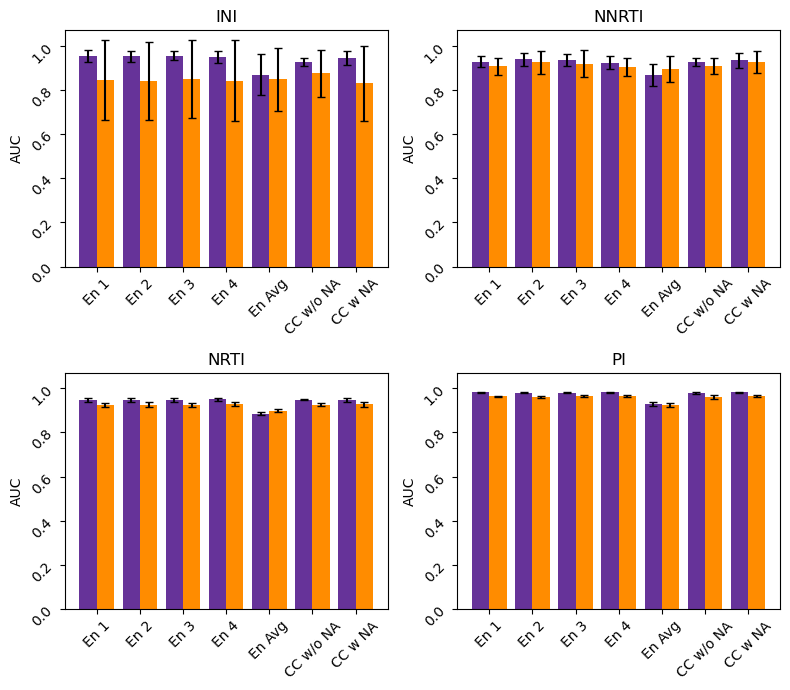

In [7]:

files = ["Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_new_save.csv"]

filename = "Classifier_Chain_5_folds_ensemble_probabilities/"

drop_na = True
metric = roc_auc_score
kwargs = {"average":"macro"}


#cc_ensemble_stat(files, filename, drop_na, metric, "Example Accuracy", kwargs)


ensemble_accs_mean = {}
ensemble_accs_std = {}

for path in filepath_list:

    chains = os.listdir(path + filename)

    chain_list = []
    chain_acc_list_mean = []
    chain_acc_list_std = []

    true_labels = None

    for chain in chains:
        #print(path+filename+chain)

        results = pd.read_csv(path + filename + chain)

        #print(path+filename+chain)

        if drop_na:
            results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        pred_labels = results.filter(regex="Pred_*")

        true_labels = results.filter(regex="True_*")
        #pred_labels = (pred_probas > 0.5) * 1.0

        subs_accs_groups = results.groupby(by="kFolds").apply(
            lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
            include_groups=False)

        #print(true_labels == true_labels_old)
        #print(pred_labels == pred_labels_old)

        chain_list.append(pred_labels)

        chain_acc_list_mean.append(subs_accs_groups.mean())
        chain_acc_list_std.append(subs_accs_groups.std())
        #chain_acc_list.append(sub_acc)

    #chain_list = np.array(chain_list)

    columns = chain_list[0].columns.values.tolist()

    ave_chain = (np.mean(np.array(chain_list), axis=0) > 0.5) * 1

    ave_chain_df = pd.DataFrame(ave_chain, columns=columns)

    #print(ave_chain_df.shape)
    kfold = results["kFolds"]

    true_labels.reset_index(drop=True, inplace=True)
    ave_chain_df.reset_index(drop=True, inplace=True)
    kfold.reset_index(drop=True, inplace=True)

    ave_chain_complete = pd.concat([true_labels, ave_chain_df, kfold], axis=1)



    #true_labels = ave_chain_df.filter(regex="True_*")
    #pred_labels = (ave_chain_df > 0.5) * 1.0

    #print(ave_chain_complete)

    subs_accs_groups = ave_chain_complete.groupby(by="kFolds").apply(
        lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
        include_groups=False)

    #sub_acc = result_handler.subset_acc(pred_labels, true_labels, nan_mode="ignore")

    chain_acc_list_mean.append(subs_accs_groups.mean())
    chain_acc_list_std.append(subs_accs_groups.std())
    #chain_acc_list.append(sub_acc)

    ensemble_accs_mean.update({path.split("/")[-1].strip("_"): chain_acc_list_mean})
    ensemble_accs_std.update({path.split("/")[-1].strip("_"): chain_acc_list_std})



df_ensemble_accs_groups_mean = pd.DataFrame(ensemble_accs_mean)
df_ensemble_accs_groups_std = pd.DataFrame(ensemble_accs_std)


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, metric,metric_args=kwargs, drop_na=drop_na)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

df_ensemble_accs_groups_mean = pd.concat([df_ensemble_accs_groups_mean,df_sub_accs_groups_mean], axis=0)
df_ensemble_accs_groups_std = pd.concat([df_ensemble_accs_groups_std, df_sub_accs_groups_std], axis=0)

df_roc_auc_mean = df_ensemble_accs_groups_mean
df_roc_auc_std = df_ensemble_accs_groups_std




drop_na = True
metric = result_handler.prc_auc_score
kwargs = {"multiclass":"ovo"}
metric_name = "AUC"

#cc_ensemble_stat(files, filename, drop_na, metric, "Example Accuracy", kwargs)


ensemble_accs_mean = {}
ensemble_accs_std = {}

for path in filepath_list:

    chains = os.listdir(path + filename)

    chain_list = []
    chain_acc_list_mean = []
    chain_acc_list_std = []

    true_labels = None

    for chain in chains:
        #print(path+filename+chain)

        results = pd.read_csv(path + filename + chain)

        #print(path+filename+chain)

        if drop_na:
            results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        pred_labels = results.filter(regex="Pred_*")

        true_labels = results.filter(regex="True_*")
        #pred_labels = (pred_probas > 0.5) * 1.0

        subs_accs_groups = results.groupby(by="kFolds").apply(
            lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
            include_groups=False)

        #print(true_labels == true_labels_old)
        #print(pred_labels == pred_labels_old)

        chain_list.append(pred_labels)

        chain_acc_list_mean.append(subs_accs_groups.mean())
        chain_acc_list_std.append(subs_accs_groups.std())
        #chain_acc_list.append(sub_acc)

    #chain_list = np.array(chain_list)

    columns = chain_list[0].columns.values.tolist()

    ave_chain = (np.mean(np.array(chain_list), axis=0) > 0.5) * 1

    ave_chain_df = pd.DataFrame(ave_chain, columns=columns)

    #print(ave_chain_df.shape)
    kfold = results["kFolds"]

    true_labels.reset_index(drop=True, inplace=True)
    ave_chain_df.reset_index(drop=True, inplace=True)
    kfold.reset_index(drop=True, inplace=True)

    ave_chain_complete = pd.concat([true_labels, ave_chain_df, kfold], axis=1)



    #true_labels = ave_chain_df.filter(regex="True_*")
    #pred_labels = (ave_chain_df > 0.5) * 1.0

    #print(ave_chain_complete)

    subs_accs_groups = ave_chain_complete.groupby(by="kFolds").apply(
        lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
        include_groups=False)

    #sub_acc = result_handler.subset_acc(pred_labels, true_labels, nan_mode="ignore")

    chain_acc_list_mean.append(subs_accs_groups.mean())
    chain_acc_list_std.append(subs_accs_groups.std())
    #chain_acc_list.append(sub_acc)

    ensemble_accs_mean.update({path.split("/")[-1].strip("_"): chain_acc_list_mean})
    ensemble_accs_std.update({path.split("/")[-1].strip("_"): chain_acc_list_std})



df_ensemble_accs_groups_mean = pd.DataFrame(ensemble_accs_mean)
df_ensemble_accs_groups_std = pd.DataFrame(ensemble_accs_std)


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, metric,metric_args=kwargs, drop_na=drop_na)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)

df_ensemble_accs_groups_mean = pd.concat([df_ensemble_accs_groups_mean,df_sub_accs_groups_mean], axis=0)
df_ensemble_accs_groups_std = pd.concat([df_ensemble_accs_groups_std, df_sub_accs_groups_std], axis=0)

df_prc_auc_mean = df_ensemble_accs_groups_mean
df_prc_auc_std = df_ensemble_accs_groups_std


#Figure

print(df_ensemble_accs_groups_mean)

models_w_TabPFN = ["CC w/o NA", "CC w NA"]


labels = ["En 1", "En 2", "En 3", "En 4", "En Avg"] + models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(8, 7))
#fig.tight_layout()

axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):


    multiplier = -0.5

    offset = width * multiplier
    rects = axs[i].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC", color="rebeccapurple")
    #axs[i].bar_label(rects, fmt='%.3f', padding=16)
    axs[i].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[i].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC", color="darkorange")
    #axs[i].bar_label(rects2, fmt='%.3f', padding=13)
    axs[i].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")



    #axs[i].bar_label(p, label_type="edge", padding=10, fmt="%.3f")
    axs[i].grid(False)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(labels)
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('AUC')
    axs[i].set_ylim(0, 1.07)
    axs[i].set_title(drug)

fig.tight_layout()

plt.savefig("../figures/05_Ensemble/Ensemble_comp_auc_new2.png")

#plt.savefig("../figures/" + fig_name)


In [33]:
# claculating p-values for ensemble


files = ["Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv", "Classifier_Chain_probabilities_5_fold_homebrew_prediction_new_save.csv"]

filename = "Classifier_Chain_5_folds_ensemble_probabilities/"

drop_na = True
metric = roc_auc_score
kwargs = {"average":"macro"}





ensemble_accs_mean = {}


for path in filepath_list:

    chains = os.listdir(path + filename)

    chain_list = []
    chain_acc_list_mean = []


    true_labels = None

    for chain in chains:


        results = pd.read_csv(path + filename + chain)



        if drop_na:
            results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        pred_labels = results.filter(regex="Pred_*")

        true_labels = results.filter(regex="True_*")


        subs_accs_groups = results.groupby(by="kFolds").apply(
            lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
            include_groups=False)



        chain_list.append(pred_labels)

        chain_acc_list_mean.append(subs_accs_groups.mean())


    columns = chain_list[0].columns.values.tolist()

    ave_chain = (np.mean(np.array(chain_list), axis=0) > 0.5) * 1

    ave_chain_df = pd.DataFrame(ave_chain, columns=columns)


    kfold = results["kFolds"]

    true_labels.reset_index(drop=True, inplace=True)
    ave_chain_df.reset_index(drop=True, inplace=True)
    kfold.reset_index(drop=True, inplace=True)

    ave_chain_complete = pd.concat([true_labels, ave_chain_df, kfold], axis=1)




    subs_accs_groups = ave_chain_complete.groupby(by="kFolds").apply(
        lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
        include_groups=False)



    chain_acc_list_mean.append(subs_accs_groups)



    ensemble_accs_mean.update({path.split("/")[-1].strip("_"): chain_acc_list_mean})


print(ensemble_accs_mean)





tmp_sub_accs_fold_mean = result_handler.calc_metrics(filepath_list, files, metric,metric_args=kwargs, drop_na=drop_na, return_groups = True)

print(tmp_sub_accs_fold_mean)

roc_auc_pt_mean = tmp_sub_accs_fold_mean

roc_auc_mean = ensemble_accs_mean



drop_na = True
metric = result_handler.prc_auc_score
kwargs = {"multiclass":"ovo"}
metric_name = "AUC"



ensemble_accs_mean = {}


for path in filepath_list:

    chains = os.listdir(path + filename)

    chain_list = []
    chain_acc_list_mean = []


    true_labels = None

    for chain in chains:


        results = pd.read_csv(path + filename + chain)


        if drop_na:
            results.dropna(subset=results.columns[results.columns.str.startswith('True_')].tolist(), inplace=True)

        pred_labels = results.filter(regex="Pred_*")

        true_labels = results.filter(regex="True_*")


        subs_accs_groups = results.groupby(by="kFolds").apply(
            lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
            include_groups=False)


        chain_list.append(pred_labels)

        chain_acc_list_mean.append(subs_accs_groups.mean())


    columns = chain_list[0].columns.values.tolist()

    ave_chain = (np.mean(np.array(chain_list), axis=0) > 0.5) * 1

    ave_chain_df = pd.DataFrame(ave_chain, columns=columns)


    kfold = results["kFolds"]

    true_labels.reset_index(drop=True, inplace=True)
    ave_chain_df.reset_index(drop=True, inplace=True)
    kfold.reset_index(drop=True, inplace=True)

    ave_chain_complete = pd.concat([true_labels, ave_chain_df, kfold], axis=1)



    subs_accs_groups = ave_chain_complete.groupby(by="kFolds").apply(
        lambda x: metric(x.filter(regex="True_*"), x.filter(regex="Pred_*"), **kwargs),
        include_groups=False)



    chain_acc_list_mean.append(list(subs_accs_groups))

    ensemble_accs_mean.update({path.split("/")[-1].strip("_"): chain_acc_list_mean})



tmp_sub_accs_fold_mean = result_handler.calc_metrics(filepath_list, files, metric,metric_args=kwargs, drop_na=drop_na, return_groups = True)


prc_auc_pt_mean = tmp_sub_accs_fold_mean

prc_auc_mean = ensemble_accs_mean



for att, meas in roc_auc_mean.items():
    print("BR vs CC")
    print(stats.ttest_ind(np.array(meas[0]), np.array(meas[4]))[1])
    print(stats.ttest_ind(np.array(meas[1]), np.array(meas[5]))[1])
    print(att)

    print(stats.ttest_ind(np.array(meas[4]), np.array(meas[0]))[1])
    print(stats.ttest_ind(np.array(meas[4]), np.array(meas[1]))[1])
    print(stats.ttest_ind(np.array(meas[4]), np.array(meas[2]))[1])
    print(stats.ttest_ind(np.array(meas[4]), np.array(meas[3]))[1])

    print(stats.ttest_ind(np.array(meas[4]), np.array(roc_auc_pt_mean[att][0]))[1])
    print(stats.ttest_ind(np.array(meas[4]), np.array(roc_auc_pt_mean[att][1]))[1])


    print("--------------------------------------------------------------------")

print("====================================================")
print("====================================================")

print("prc auc")
for att, meas in prc_auc_mean.items():
    print("BR vs CC")
    print(stats.ttest_ind(np.array(meas[0]), np.array(meas[4]))[1])
    print(stats.ttest_ind(np.array(meas[1]), np.array(meas[5]))[1])
    print(att)
    print(stats.ttest_ind(np.array(meas[4]), np.array(meas[0]))[1])
    print(stats.ttest_ind(np.array(meas[4]), np.array(meas[1]))[1])
    print(stats.ttest_ind(np.array(meas[4]), np.array(meas[2]))[1])
    print(stats.ttest_ind(np.array(meas[4]), np.array(meas[3]))[1])

    print(stats.ttest_ind(np.array(meas[4]), np.array(roc_auc_pt_mean[att][0]))[1])
    print(stats.ttest_ind(np.array(meas[4]), np.array(roc_auc_pt_mean[att][1]))[1])

    print("--------------------------------------------------------------------")



{'INI': [0.953981567664638, 0.9520174863159049, 0.9542804867971141, 0.950207871948978, kFolds
0.0    0.874889
1.0    0.954132
2.0    0.893452
3.0    0.913996
4.0    0.711164
dtype: float64], 'NNRTI': [0.9274578657197786, 0.9389261356420573, 0.9357193875569809, 0.9237590889063749, kFolds
0.0    0.918464
1.0    0.821402
2.0    0.852097
3.0    0.828069
4.0    0.925413
dtype: float64], 'NRTI': [0.9459589038024767, 0.947732979934521, 0.9474188875828524, 0.9499526845016085, kFolds
0.0    0.885092
1.0    0.891630
2.0    0.889611
3.0    0.872902
4.0    0.881611
dtype: float64], 'PI': [0.9810623542668239, 0.9799322616811514, 0.9808972118786576, 0.9814100698682378, kFolds
0.0    0.921069
1.0    0.929591
2.0    0.926013
3.0    0.943137
4.0    0.922673
dtype: float64]}
{'INI': [[0.9232974813857167, 0.907499637786149, 0.9273328081232493, 0.9243577024827025, 0.9575149115590292], [0.955482456140351, 0.9444686965695369, 0.9489568918617687, 0.9832621082621082, 0.8937590187590188]], 'NNRTI': [[0.9138813

## Usage of label information improves prediction

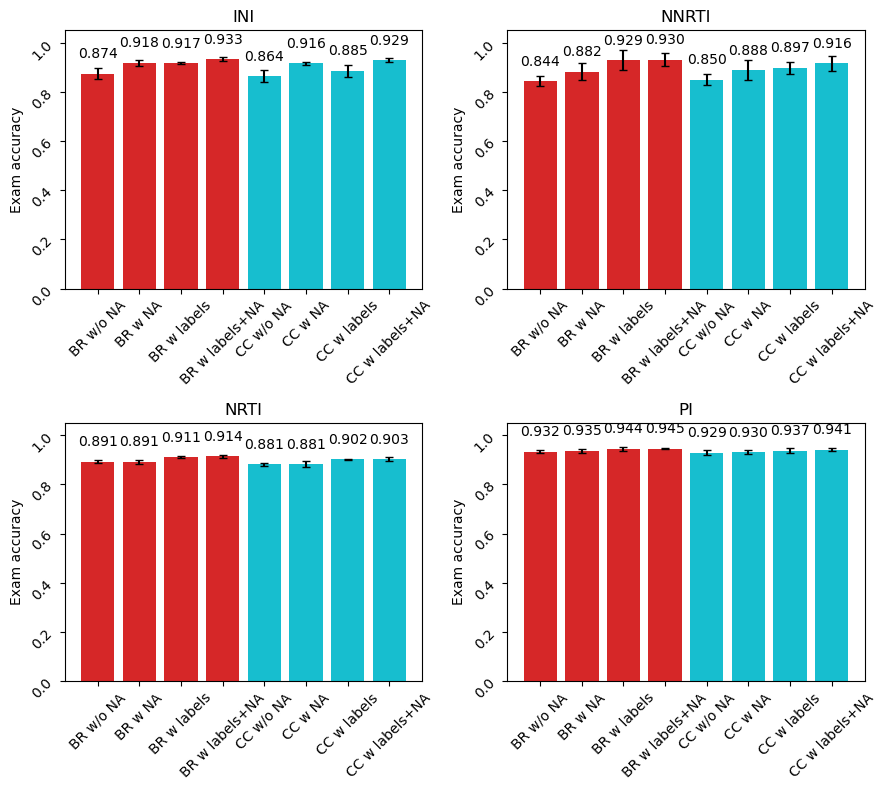

In [8]:
files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv","Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_use_labels.csv","Binary_Relevance_5_fold_homebrew_prediction_use_labels_wNaN.csv" ,"Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv","Classifier_Chain_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_use_labels.csv", "Classifier_Chain_5_fold_use_labels_wNaN.csv"]


tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)


models_w_TabPFN = ["BR w/o NA", "BR w NA", "BR w labels","BR w labels+NA", "CC w/o NA", "CC w NA", "CC w labels", "CC w labels+NA"]



color = ["tab:red"] * 4 + ["tab:cyan"] * 4

fig, axs = plt.subplots(2, 2, figsize=(9, 8))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge", fmt='%.3f', padding=9)

    axs[i].grid(False)
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('Exam accuracy')
    axs[i].set_ylim(0, 1.05)
    axs[i].set_title(drug)

fig.tight_layout()

plt.savefig("../figures/06_label_info/label_info_exam_acc_new2.png")



In [26]:
#calculating p-value for PT methods in general


files = ["Binary_Relevance_5_fold_MOC_prediction_new_save.csv","Binary_Relevance_5_fold_homebrew_prediction_new_save.csv", "Binary_Relevance_5_fold_homebrew_prediction_use_labels.csv","Binary_Relevance_5_fold_homebrew_prediction_use_labels_wNaN.csv" ,"Classifier_Chain_5_fold_homebrew_prediction_woNaN_new_save.csv","Classifier_Chain_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_5_fold_use_labels.csv", "Classifier_Chain_5_fold_use_labels_wNaN.csv"]


tmp_sub_accs_fold_mean = result_handler.calc_metrics(filepath_list, files, result_handler.exam_acc,metric_args={}, drop_na=True, return_groups=True)

#df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
#df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)




for att, meas in tmp_sub_accs_fold_mean.items():
    print("BR vs CC")
    print(stats.ttest_ind(np.array(meas[0]), np.array(meas[4]))[1])
    print(stats.ttest_ind(np.array(meas[1]), np.array(meas[5]))[1])
    print(att)
    i = 0
    print("BR")
    print("-NA vs +NA")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+1]))[1])
    print("-NA vs -NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+2]))[1])


    print("-NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+3]))[1])
    print("+NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i+1]), np.array(meas[i+3]))[1])

    i = 4
    print("CC")
    print("-NA vs +NA")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+1]))[1])
    print("-NA vs -NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+2]))[1])

    print("-NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+3]))[1])
    print("+NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i+1]), np.array(meas[i+3]))[1])
    print("--------------------------------------------------------------------")



INI
BR
+NA vs +NA+lab
0.051236443512792954
CC
+NA vs +NA+lab
0.027475735835010506
--------------------------------------------------------------------
NNRTI
BR
+NA vs +NA+lab
0.039405673686288056
CC
+NA vs +NA+lab
0.25009831135483573
--------------------------------------------------------------------
NRTI
BR
+NA vs +NA+lab
0.00119881370502115
CC
+NA vs +NA+lab
0.015625906273889382
--------------------------------------------------------------------
PI
BR
+NA vs +NA+lab
0.026434866950078476
CC
+NA vs +NA+lab
0.039152565080808825
--------------------------------------------------------------------


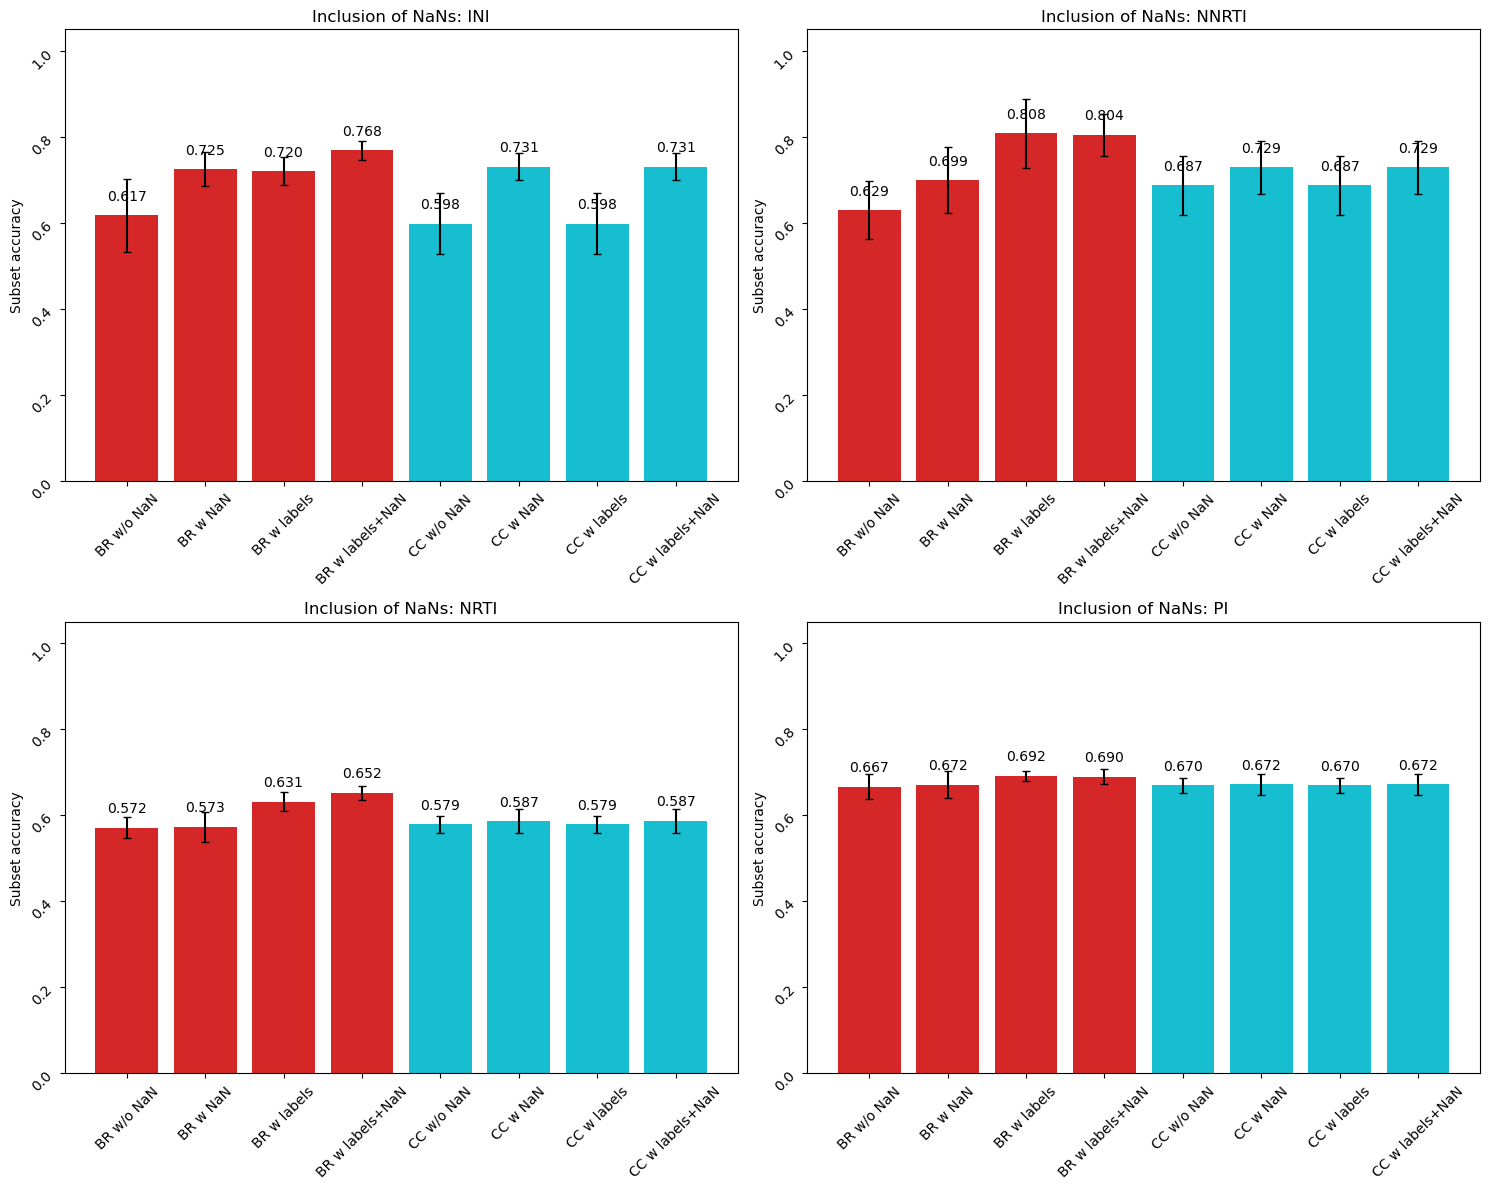

In [62]:



tmp_sub_accs_fold_mean, tmp_sub_accs_fold_std = result_handler.calc_metrics(filepath_list, files, result_handler.subset_acc,metric_args={}, drop_na=True)

df_sub_accs_groups_mean = pd.DataFrame(tmp_sub_accs_fold_mean)
df_sub_accs_groups_std = pd.DataFrame(tmp_sub_accs_fold_std)


fig, axs = plt.subplots(2, 2, figsize=(15, 12))

axs = axs.flatten()

for i, drug in enumerate(df_sub_accs_groups_mean.columns.values.tolist()):


    p = axs[i].bar(models_w_TabPFN, df_sub_accs_groups_mean[drug], color=color)
    axs[i].errorbar(models_w_TabPFN, df_sub_accs_groups_mean[drug], yerr=df_sub_accs_groups_std[drug],capsize=3, fmt="none", ecolor="black")

    axs[i].bar_label(p, label_type="edge", fmt='%.3f', padding=9)

    axs[i].tick_params(rotation=45)

    axs[i].set_ylabel('Subset accuracy')
    axs[i].set_ylim(0, 1.05)
    axs[i].set_title('Inclusion of NaNs: ' + drug)

fig.tight_layout()

plt.savefig("../figures/06_label_info/label_info_subset_acc.png")



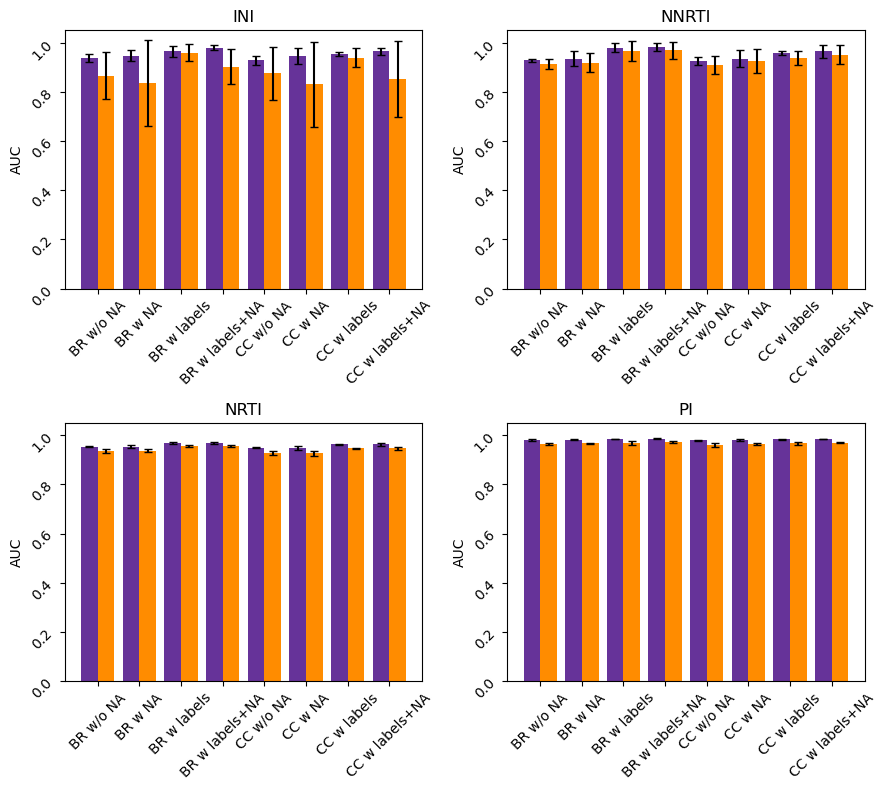

In [10]:

files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv","Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", "Binary_Relevance_probabilities_5_fold_homebrew_prediction_use_labels.csv","Binary_Relevance_probabilities_5_fold_homebrew_prediction_use_labels_wNaN.csv" ,"Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv","Classifier_Chain_probabilities_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_use_labels.csv", "Classifier_Chain_probabilities_5_fold_use_labels_wNaN.csv"]

tmp_roc_auc_mean, tmp_roc_auc_std = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True)

df_roc_auc_mean = pd.DataFrame(tmp_roc_auc_mean)
df_roc_auc_std = pd.DataFrame(tmp_roc_auc_std)

tmp_prc_auc_mean, tmp_prc_auc_std = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovo"}, drop_na=True)

df_prc_auc_mean = pd.DataFrame(tmp_prc_auc_mean)
df_prc_auc_std = pd.DataFrame(tmp_prc_auc_std)




labels = models_w_TabPFN

x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, axs = plt.subplots(2, 2, figsize=(9, 8))


axs = axs.flatten()

means = []

for i, drug in enumerate(df_prc_auc_mean.columns.values.tolist()):


    multiplier = -0.5

    offset = width * multiplier
    rects = axs[i].bar(x + offset, df_roc_auc_mean[drug], width, label="ROC AUC", color="rebeccapurple")
    #axs[i].bar_label(rects, fmt='%.3f', padding=9)
    axs[i].errorbar(x + offset, df_roc_auc_mean[drug], yerr=df_roc_auc_std[drug],capsize=3, fmt="none", ecolor="black")
    multiplier += 1

    offset = width * multiplier
    rects2 = axs[i].bar(x + offset, df_prc_auc_mean[drug], width, label="PRC AUC", color="darkorange")
    #axs[i].bar_label(rects2, fmt='%.3f', padding=9)
    axs[i].errorbar(x + offset, df_prc_auc_mean[drug], yerr=df_prc_auc_std[drug],capsize=3, fmt="none", ecolor="black")

    multiplier += 1




    axs[i].grid(False)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(models_w_TabPFN)
    axs[i].tick_params(rotation=45)
    axs[i].set_ylabel('AUC')
    axs[i].set_ylim(0,  1.05)
    axs[i].set_title(drug)

fig.tight_layout()

#plt.show()

plt.savefig("../figures/06_label_info/label_info_auc_new2.png")


In [25]:
#calculating p-values for PT methods in general for ROC AUC and PRC AUC

files = ["Binary_Relevance_probabilities_5_fold_MOC_prediction_new_save.csv","Binary_Relevance_probabilities_5_fold_homebrew_prediction_new_save.csv", "Binary_Relevance_probabilities_5_fold_homebrew_prediction_use_labels.csv","Binary_Relevance_probabilities_5_fold_homebrew_prediction_use_labels_wNaN.csv" ,"Classifier_Chain_probabilities_5_fold_homebrew_prediction_woNaN_new_save.csv","Classifier_Chain_probabilities_5_fold_homebrew_prediction_new_save.csv", "Classifier_Chain_probabilities_5_fold_use_labels.csv", "Classifier_Chain_probabilities_5_fold_use_labels_wNaN.csv"]

tmp_roc_auc_mean = result_handler.calc_metrics(filepath_list, files, roc_auc_score,metric_args={"average": "macro"}, drop_na=True, return_groups=True)



tmp_prc_auc_mean = result_handler.calc_metrics(filepath_list, files, result_handler.prc_auc_score,metric_args={"multiclass":"ovo"}, drop_na=True, return_groups=True)




for att, meas in tmp_roc_auc_mean.items():
    print("BR vs CC")
    print(stats.ttest_ind(np.array(meas[0]), np.array(meas[4]))[1])
    print(stats.ttest_ind(np.array(meas[1]), np.array(meas[5]))[1])
    print(att)
    i = 0
    print("BR")
    print("-NA vs +NA")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+1]))[1])
    print("-NA vs -NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+2]))[1])


    print("-NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+3]))[1])
    print("+NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i+1]), np.array(meas[i+3]))[1])

    i = 4
    print("CC")
    print("-NA vs +NA")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+1]))[1])
    print("-NA vs -NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+2]))[1])

    print("-NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+3]))[1])
    print("+NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i+1]), np.array(meas[i+3]))[1])

    print("--------------------------------------------------------------------")

print("====================================================")
print("====================================================")

print("prc auc")
for att, meas in tmp_prc_auc_mean.items():
    print("BR vs CC")
    print(stats.ttest_ind(np.array(meas[0]), np.array(meas[4]))[1])
    print(stats.ttest_ind(np.array(meas[1]), np.array(meas[5]))[1])
    print(att)
    i = 0
    print("BR")
    print("-NA vs +NA")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+1]))[1])
    print("-NA vs -NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+2]))[1])


    print("-NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+3]))[1])
    print("+NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i+1]), np.array(meas[i+3]))[1])

    i = 4
    print("CC")
    print("-NA vs +NA")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+1]))[1])
    print("-NA vs -NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+2]))[1])

    print("-NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i]), np.array(meas[i+3]))[1])
    print("+NA vs +NA+lab")
    print(stats.ttest_ind(np.array(meas[i+1]), np.array(meas[i+3]))[1])

    print("--------------------------------------------------------------------")



INI
BR
+NA vs +NA+lab
0.02004480233500512
CC
+NA vs +NA+lab
0.25172814883552797
--------------------------------------------------------------------
NNRTI
BR
+NA vs +NA+lab
0.016268112869542686
CC
+NA vs +NA+lab
0.1534982885458673
--------------------------------------------------------------------
NRTI
BR
+NA vs +NA+lab
0.0031901611031436286
CC
+NA vs +NA+lab
0.015676519672714464
--------------------------------------------------------------------
PI
BR
+NA vs +NA+lab
0.02425123675687807
CC
+NA vs +NA+lab
0.05279047319008315
--------------------------------------------------------------------
prc auc
INI
BR
+NA vs +NA+lab
0.448605080085388
CC
+NA vs +NA+lab
0.8327904722964847
--------------------------------------------------------------------
NNRTI
BR
+NA vs +NA+lab
0.05810069388752428
CC
+NA vs +NA+lab
0.3890368795725001
--------------------------------------------------------------------
NRTI
BR
+NA vs +NA+lab
0.001446089905537927
CC
+NA vs +NA+lab
0.006260143176560504
------------